# Project P009 — AI Model Inversion Attack and Defense

### Team 39 — G04

**Members:**
- BENAISSA Bochra
- LARMED Kahina
- NEGAB Rania
- SAKRI Anfel
- HADBI Sarra

---

## Project Introduction

This project is about **AI privacy and security**. We train a machine learning model
to detect credit card fraud, and then we study how that model can accidentally
leak private information about the people it was trained on.

This is called a **Model Inversion Attack** — where an attacker uses the trained
model to reconstruct private details about the training data, without ever seeing
the original dataset.

We also implement **defenses** to protect against these attacks.

---

### The Dataset

We use the **Credit Card Fraud Detection** dataset from Kaggle.
It contains real credit card transactions made by US cardholders.

Each row is one transaction and includes:
- **Personal details** — cardholder name, gender, date of birth, job, home address
- **Transaction details** — amount, date, time, merchant name, merchant category
- **Location** — cardholder home coordinates and merchant coordinates
- **Label** — `is_fraud`: 0 means the transaction is legitimate, 1 means it is fraud

The dataset has **1,296,675 transactions** in the training set,
but only **7,506 of them are fraud** (0.58%) — making fraud very rare and hard to detect.

---

### Project Workflow

| Member | Role | Task |
|--------|------|------|
| **Member 01** | Data & EDA | Clean the data, explore it, and prepare features for the model |
| **Member 02** | Model Training | Build and train the fraud detection neural network (MLP) |
| **Member 03** | Attack | Run a model inversion attack to reconstruct private transaction profiles |
| **Member 04** | Attack + Defense | Run membership inference attack and apply differential privacy defense |
| **Member 05** | Defense + Evaluation | Apply regularization defenses and compare all results |

---
## Data Preparation & Exploratory Data Analysis
**Student:** LARMED Kahina | **Group:** 4

This section covers:

- Loading and cleaning the raw credit card transaction data
- Checking for missing values, duplicate rows, and class distribution
- Exploring the data through visualizations to find patterns linked to fraud
- Engineering new features: cardholder age, home-to-merchant distance, and time features
- Encoding text columns into numbers and scaling all features to the same range
- Saving all processed files to disk for Members 02–05 to use directly

---
## Section 0 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

import os, joblib, json

# Makes results the same every run
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 1 — Load and Clean the Data

We load both CSV files. The training set is used to build the model, and the test set is used to evaluate it.
We always keep them separate to prevent **data leakage**.

> **Data leakage** = accidentally letting test data influence the training process, which gives fake results.
> We avoid this by never fitting any transformation on the test set.

In [2]:
train_df = pd.read_csv('fraudTrain.csv', index_col=0)
test_df  = pd.read_csv('fraudTest.csv',  index_col=0)

print(f'Training set : {train_df.shape[0]:,} rows, {train_df.shape[1]} columns')
print(f'Test set     : {test_df.shape[0]:,} rows, {test_df.shape[1]} columns')
print(f'\nColumns: {list(train_df.columns)}')

Training set : 1,296,675 rows, 22 columns
Test set     : 555,719 rows, 22 columns

Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [3]:
# Quick look at the first few rows
train_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [4]:
# Data types and non-null counts
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

The dataset has 22 columns covering transaction details, merchant info, and cardholder personal data.
The column we want to predict is `is_fraud` (0 = legitimate, 1 = fraud).


### 1.1 — Check for Missing Values

Missing values need to be found before any analysis. If ignored, they cause errors or wrong results.

In [5]:
train_nulls = train_df.isnull().sum()
test_nulls  = test_df.isnull().sum()

null_summary = pd.DataFrame({'Train': train_nulls, 'Test': test_nulls})
null_summary = null_summary[null_summary.sum(axis=1) > 0]

if null_summary.empty:
    print('No missing values found in either dataset.')
else:
    print('Missing values found:')
    display(null_summary)

No missing values found in either dataset.


No missing values — every row is complete, so no filling or dropping is needed.

### 1.2 — Check for Duplicate Rows

Duplicate rows repeat the same transaction, which can bias the model.

In [6]:
train_dups = train_df.duplicated().sum()
test_dups  = test_df.duplicated().sum()

print(f'Duplicates in training set : {train_dups}')
print(f'Duplicates in test set     : {test_dups}')

if train_dups > 0:
    train_df = train_df.drop_duplicates()
    print('Training duplicates removed.')

if test_dups > 0:
    test_df = test_df.drop_duplicates()
    print('Test duplicates removed.')

if train_dups == 0 and test_dups == 0:
    print('No duplicates found — no rows removed.')

Duplicates in training set : 0
Duplicates in test set     : 0
No duplicates found — no rows removed.


### 1.3 — Class Distribution

Fraud is rare in real life, so fraud datasets are almost always **imbalanced**.
We check exactly how imbalanced this one is.

In [7]:
train_counts = train_df['is_fraud'].value_counts()
test_counts  = test_df['is_fraud'].value_counts()

print('=== Training Set ===')
print(f'  Legitimate (0) : {train_counts[0]:>10,}  ({train_counts[0]/len(train_df)*100:.2f}%)')
print(f'  Fraud      (1) : {train_counts[1]:>10,}  ({train_counts[1]/len(train_df)*100:.2f}%)')
print(f'  Imbalance ratio: {train_counts[0]//train_counts[1]}:1')

print('\n=== Test Set ===')
print(f'  Legitimate (0) : {test_counts[0]:>10,}  ({test_counts[0]/len(test_df)*100:.2f}%)')
print(f'  Fraud      (1) : {test_counts[1]:>10,}  ({test_counts[1]/len(test_df)*100:.2f}%)')

=== Training Set ===
  Legitimate (0) :  1,289,169  (99.42%)
  Fraud      (1) :      7,506  (0.58%)
  Imbalance ratio: 171:1

=== Test Set ===
  Legitimate (0) :    553,574  (99.61%)
  Fraud      (1) :      2,145  (0.39%)


The dataset is heavily imbalanced — only **0.58%** of training transactions are fraud (7,506 out of 1,296,675).

**What this means :**
A model that always predicts "legitimate" would be 99.42% accurate but useless — it would never catch fraud.
We must handle this imbalance using class weights or oversampling, and should evaluate using **AUC-ROC and F1**, not accuracy.

### 1.4 — Statistical Summary

A quick overview of the range and distribution of all numerical columns.

In [8]:
train_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000
mean,417192042079726656.0000,70.3510,48800.6711,38.5376,-90.2263,88824.4406,1349243636.7261,38.5373,-90.2265,0.0058
std,1308806447000789248.0000,160.3160,26893.2225,5.0758,13.7591,301956.3607,12841278.4234,5.1098,13.7711,0.0759
min,60416207185.0000,1.0000,1257.0000,20.0271,-165.6723,23.0000,1325376018.0000,19.0278,-166.6712,0.0000
25%,180042946491150.0000,9.6500,26237.0000,34.6205,-96.7980,743.0000,1338750742.5000,34.7336,-96.8973,0.0000
50%,3521417320836166.0000,47.5200,48174.0000,39.3543,-87.4769,2456.0000,1349249747.0000,39.3657,-87.4384,0.0000
75%,4642255475285942.0000,83.1400,72042.0000,41.9404,-80.1580,20328.0000,1359385375.5000,41.9572,-80.2368,0.0000
max,4992346398065154048.0000,28948.9000,99783.0000,66.6933,-67.9503,2906700.0000,1371816817.0000,67.5103,-66.9509,1.0000


`amt` has a mean of 70 but goes up to 28,948 --> the distribution is very skewed
(most transactions are small, a few are very large).

Also notice that features have very different scales: `amt` can reach 28,000
while `hour` only goes from 0 to 23. This is exactly why we apply **StandardScaler**
in Section 3 to put all features on the same scale.

---
## Section 2 — Exploratory Data Analysis (EDA)

We use charts to find patterns linked to fraud.
Each chart is followed by a written interpretation.

### 2.1 — Class Imbalance Chart

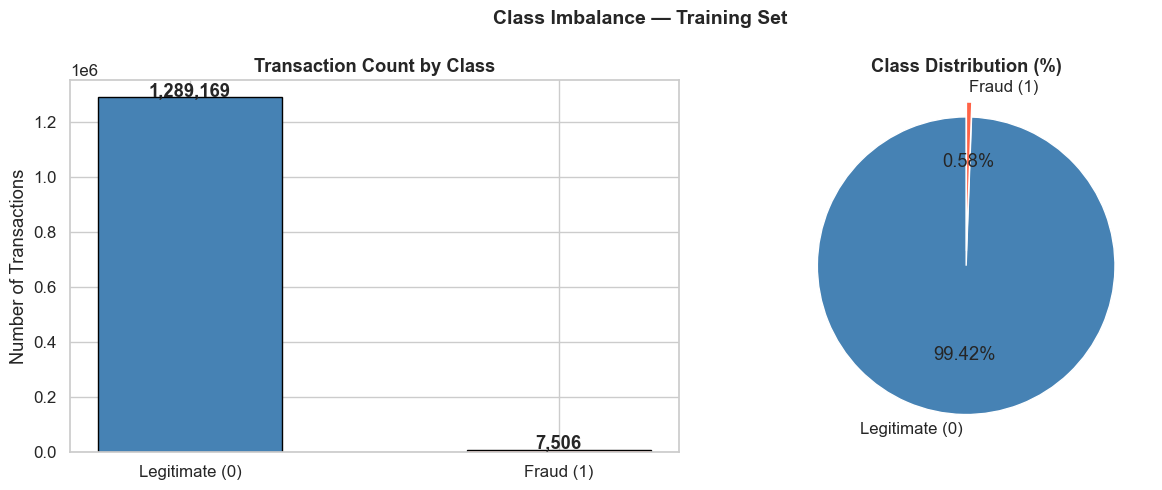

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['steelblue', 'tomato']

# Bar chart
bars = axes[0].bar(labels, train_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

# Pie chart
axes[1].pie(train_counts.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('Class Imbalance — Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
The fraud class is tiny — only 0.58% of all transactions.
The pie chart makes this clear: the fraud slice is almost invisible.
Any model trained on this data must account for this imbalance, otherwise it will simply learn to predict everything as legitimate.

### 2.2 — Transaction Amount by Class

We compare transaction amounts between fraud and legitimate cases.

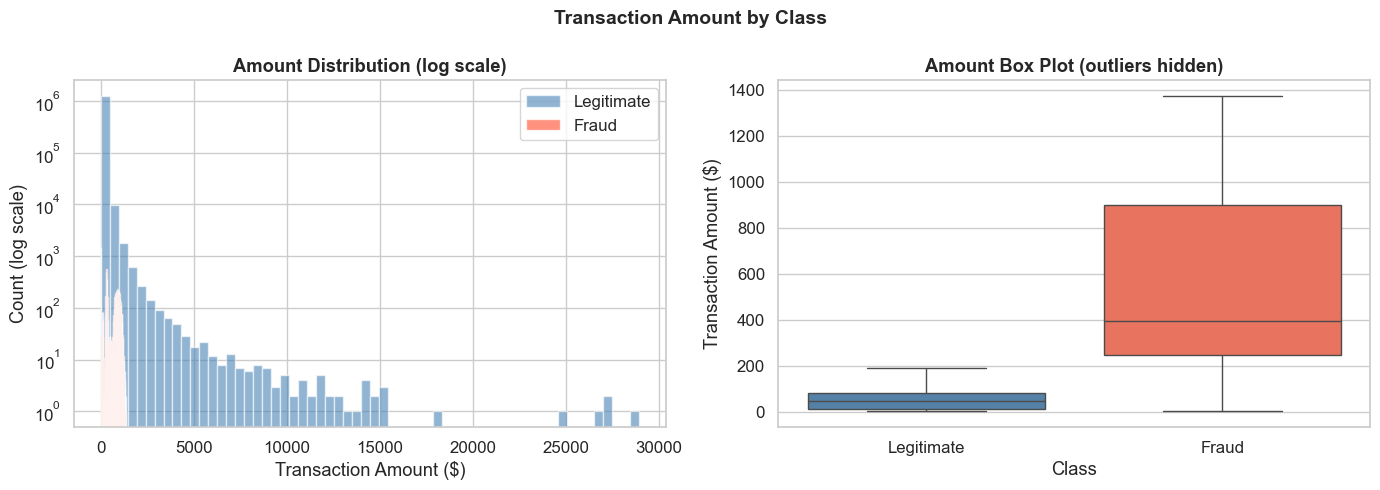

Legitimate — mean: $67.67, median: $47.28
Fraud      — mean: $531.32, median: $396.50


In [11]:
legit = train_df[train_df['is_fraud'] == 0]['amt']
fraud = train_df[train_df['is_fraud'] == 1]['amt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — log scale because class sizes are very different
axes[0].hist(legit, bins=60, alpha=0.6, color='steelblue', label='Legitimate', log=True)
axes[0].hist(fraud, bins=60, alpha=0.7, color='tomato',    label='Fraud',      log=True)
axes[0].set_title('Amount Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].legend()

# Box plot — outliers hidden so we can see the boxes clearly
plot_data = pd.DataFrame({
    'Amount': pd.concat([legit, fraud]),
    'Class' : ['Legitimate'] * len(legit) + ['Fraud'] * len(fraud)
})
sns.boxplot(data=plot_data, x='Class', y='Amount',
            palette=['steelblue', 'tomato'], showfliers=False, ax=axes[1])
axes[1].set_title('Amount Box Plot (outliers hidden)', fontweight='bold')
axes[1].set_ylabel('Transaction Amount ($)')

plt.suptitle('Transaction Amount by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Legitimate — mean: ${:.2f}, median: ${:.2f}'.format(legit.mean(), legit.median()))
print('Fraud      — mean: ${:.2f}, median: ${:.2f}'.format(fraud.mean(), fraud.median()))

**Interpretation:**
Fraudulent transactions are **much larger** on average.

- Legitimate mean: **$67.67**, median: **$47.28**
- Fraud mean: **$531.32**, median: **$396.50**

The box plot confirms this clearly — the fraud box sits much higher.
`amt` is likely the **most predictive single feature** for Member 02's model.


### 2.3 — Fraud Rate by Merchant Category

We look at what percentage of transactions in each category are fraudulent.

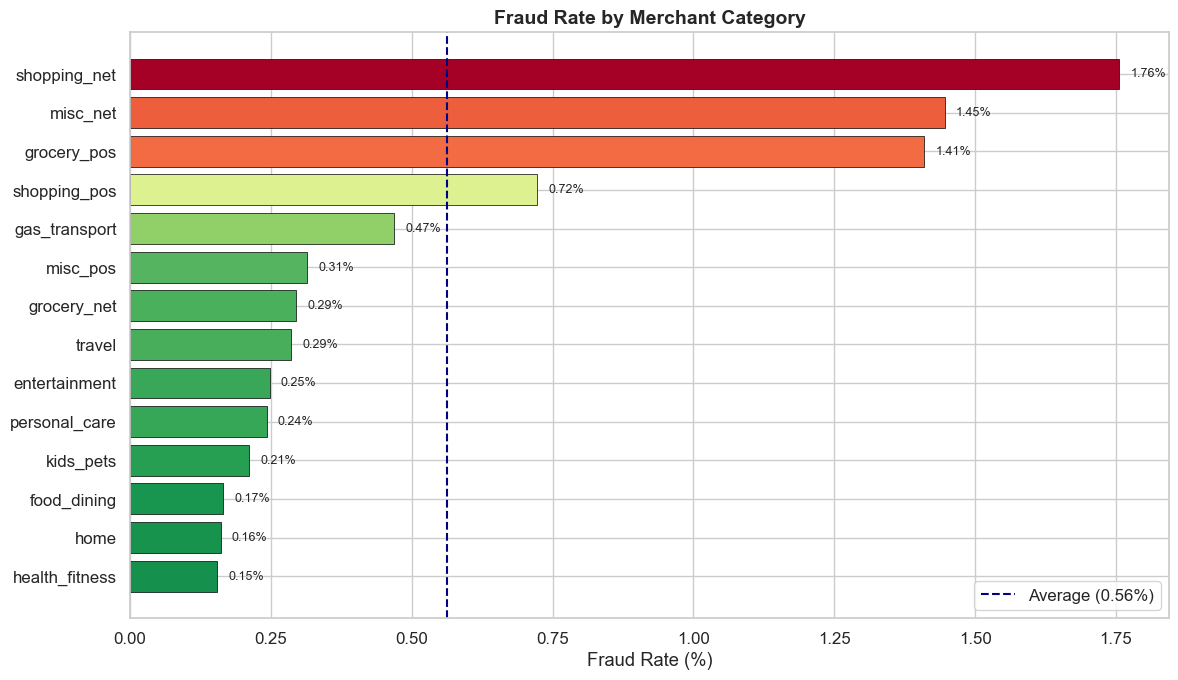

In [12]:
cat_stats = (train_df
             .groupby('category')['is_fraud']
             .agg(['mean', 'sum', 'count'])
             .reset_index())
cat_stats.columns = ['category', 'fraud_rate', 'fraud_count', 'total']
cat_stats['fraud_pct'] = cat_stats['fraud_rate'] * 100
cat_stats = cat_stats.sort_values('fraud_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.RdYlGn_r(cat_stats['fraud_pct'] / cat_stats['fraud_pct'].max())
bars = ax.barh(cat_stats['category'], cat_stats['fraud_pct'],
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, cat_stats['fraud_pct']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

mean_rate = cat_stats['fraud_pct'].mean()
ax.axvline(mean_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'Average ({mean_rate:.2f}%)')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Merchant Category', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_fraud_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
Online categories like `shopping_net` and `grocery_net` have the **highest fraud rates**.
Online transactions don't require a physical card, making them easier to abuse.
In-person categories like `gas_transport` and `food_dining` are much safer.

`category` will be one of the most useful features for Member 02's model.

### 2.4 — Fraud Rate Over Time

We look at how fraud rates change by hour of day, day of week, and month.

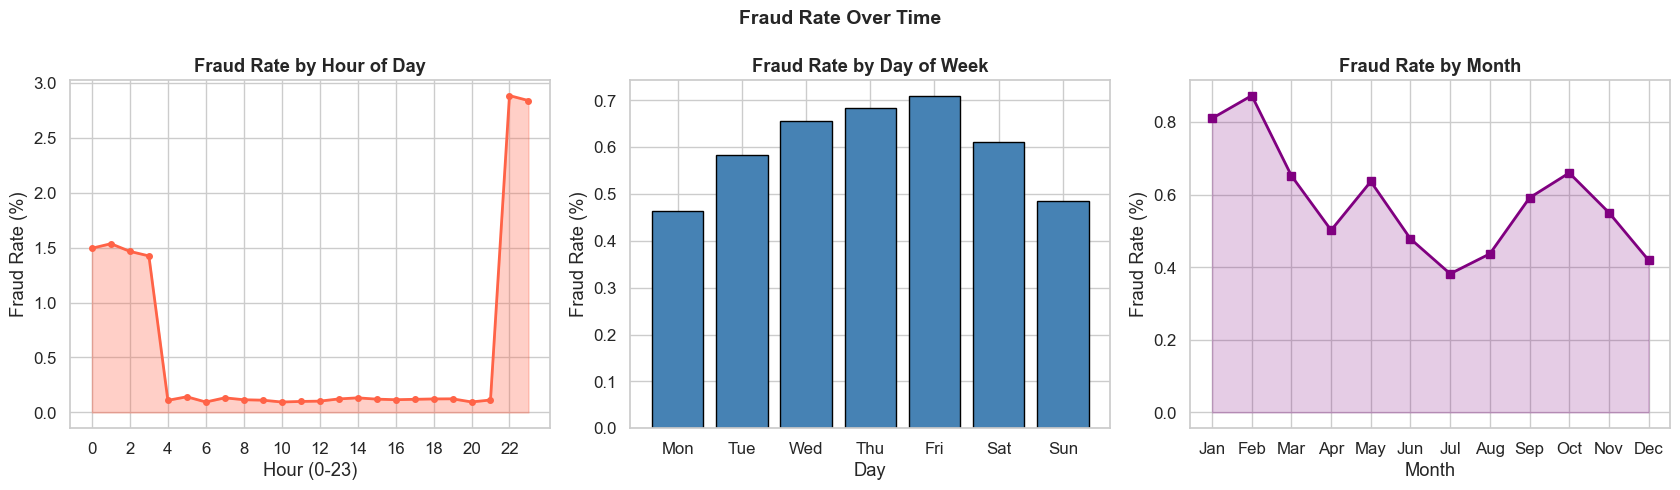

In [13]:
# Parse datetime and extract time features
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['hour']        = train_df['trans_date_trans_time'].dt.hour
train_df['day_of_week'] = train_df['trans_date_trans_time'].dt.dayofweek
train_df['month']       = train_df['trans_date_trans_time'].dt.month

hourly  = train_df.groupby('hour')['is_fraud'].mean() * 100
daily   = train_df.groupby('day_of_week')['is_fraud'].mean() * 100
monthly = train_df.groupby('month')['is_fraud'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Hourly
axes[0].fill_between(hourly.index, hourly.values, alpha=0.3, color='tomato')
axes[0].plot(hourly.index, hourly.values, color='tomato', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24, 2))

# Daily
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_labels, daily.values, color='steelblue', edgecolor='black')
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')

# Monthly
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].plot([month_labels[m-1] for m in monthly.index], monthly.values,
             color='purple', linewidth=2, marker='s', markersize=6)
axes[2].fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='purple')
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels([month_labels[m-1] for m in monthly.index])
axes[2].set_title('Fraud Rate by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Fraud Rate (%)')

plt.suptitle('Fraud Rate Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_fraud_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

**Hour of day** is the strongest time-based pattern — fraud spikes sharply between **midnight and 3am**,
when cardholders are asleep and less likely to notice suspicious activity.

Day of week shows little variation , no single day stands out.

Monthly patterns are also mild , no dramatic seasonal spike.
`hour` is the most useful time feature and will be included in the model.

### 2.5 — Correlation Heatmap

A correlation heatmap shows how strongly each numerical feature relates to every other feature.

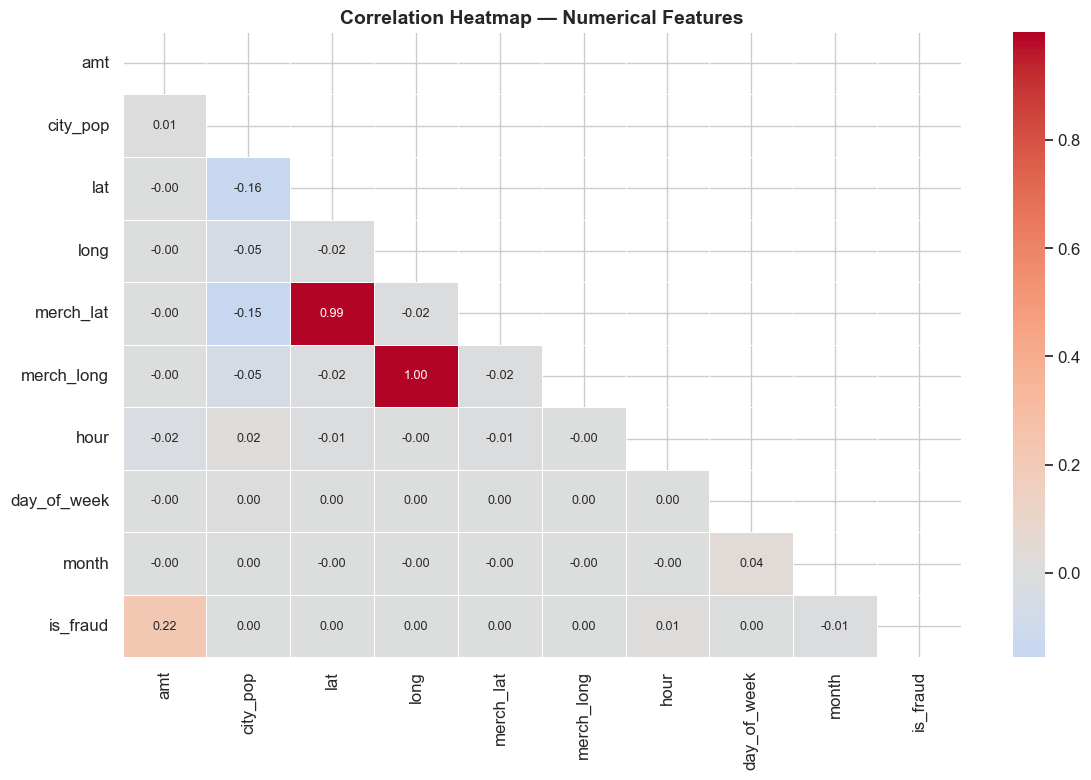

In [14]:
heat_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long',
             'hour', 'day_of_week', 'month', 'is_fraud']

corr = train_df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (it's a mirror)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9}, ax=ax)

ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
Values close to **+1** mean strong positive relationship, close to **-1** mean strong negative, and near **0** means no relationship.

Looking at the `is_fraud` row:
- `amt` has the **highest correlation with fraud** , confirms what we saw in the amount chart
- All other features show very low individual correlation with fraud

This tells us no single feature alone is enough to detect fraud.
The patterns are complex and non-linear.

---
## Section 3 — Feature Engineering & Preprocessing

We create new useful features from existing columns, convert text columns to numbers,
and scale everything to the same range.

In [15]:
# Apply the same time features to the test set
test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])
test_df['hour']        = test_df['trans_date_trans_time'].dt.hour
test_df['day_of_week'] = test_df['trans_date_trans_time'].dt.dayofweek
test_df['month']       = test_df['trans_date_trans_time'].dt.month

print('Time features added to test set.')

Time features added to test set.


### 3.1 — New Feature: Age

`dob` is the cardholder's date of birth stored as text (e.g. `1988-03-09`).
We convert it to **age in years at the time of the transaction** — a number the model can use.

Age is a private personal attribute , a model inversion attack could potentially recover it.

In [16]:
def compute_age(df):
    dob = pd.to_datetime(df['dob'])
    age = (df['trans_date_trans_time'] - dob).dt.days // 365
    return age

train_df['age'] = compute_age(train_df)
test_df['age']  = compute_age(test_df)

print('Age feature created.')
print(train_df['age'].describe())

Age feature created.
count   1296675.0000
mean         45.5282
std          17.4090
min          13.0000
25%          32.0000
50%          44.0000
75%          57.0000
max          95.0000
Name: age, dtype: float64


Age ranges from **13 to 95 years**, with a mean of about **45 years**. These are realistic values.
This new `age` column replaces the raw `dob` text column.

### 3.2 — New Feature: Distance (km)

The dataset has the cardholder's home coordinates (`lat`, `long`) and the merchant's coordinates (`merch_lat`, `merch_long`).
We calculate the straight-line distance between them in km using the **Haversine formula**.

A large distance between home and merchant could be a sign of unusual activity "a fraud signal".
Location is also one of the most sensitive private attributes in this dataset.

In [17]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    # Convert degrees to radians — done separately because lat1 etc. are pandas Series
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

train_df['distance_km'] = haversine_distance(
    train_df['lat'], train_df['long'],
    train_df['merch_lat'], train_df['merch_long'])

test_df['distance_km'] = haversine_distance(
    test_df['lat'], test_df['long'],
    test_df['merch_lat'], test_df['merch_long'])

print('Distance feature created.')
print(train_df['distance_km'].describe())

Distance feature created.
count   1296675.0000
mean         76.1147
std          29.1169
min           0.0223
25%          55.3349
50%          78.2318
75%          98.5033
max         152.1172
Name: distance_km, dtype: float64


Distance ranges from nearly **0 km** (merchant is very close) to **152 km**, with a mean of **76 km**.
Transactions made very far from home may indicate fraud.

### 3.3 — Feature Selection

We drop columns that are:
- **Unique identifiers** (card number, transaction ID) — every row is different so there's nothing to learn
- **Already replaced** by engineered features (e.g. `dob` → `age`)
- **Too many unique text values** to encode meaningfully (e.g. merchant name has thousands of unique values)

In [18]:
# Columns to drop
DROP_COLS = [
    'trans_date_trans_time',  # replaced by hour, day_of_week, month
    'cc_num',                 # unique card number — no signal
    'first', 'last',          # cardholder names
    'street',                 # too specific; lat/long capture location better
    'trans_num',              # unique transaction ID
    'unix_time',              # same info as datetime
    'dob',                    # replaced by age
    'merchant',               # too many unique values
    'zip',                    # lat/long are more precise
]

# Categorical columns we keep and will encode
CAT_COLS = ['category', 'gender', 'city', 'state', 'job']

# Numerical columns we keep as-is
NUM_COLS = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long',
            'hour', 'day_of_week', 'month', 'age', 'distance_km']

print(f'Dropping    : {len(DROP_COLS)} columns')
print(f'Numerical   : {len(NUM_COLS)} columns')
print(f'Categorical : {len(CAT_COLS)} columns (will be encoded)')

Dropping    : 10 columns
Numerical   : 11 columns
Categorical : 5 columns (will be encoded)


### 3.4 — Encode Categorical Columns

ML models only work with numbers, not text.
We use **Label Encoding** — each unique text value gets a unique integer (e.g. `shopping_net` → 10).

**Important:** we fit the encoder **only on the training set**, then apply it to both sets.
This prevents data leakage. Any value in the test set that was not seen during training gets -1.

In [19]:
encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()

    # Learn the mapping from the training set
    train_df[col + '_enc'] = le.fit_transform(train_df[col].astype(str))

    # Apply the same mapping to the test set
    known = set(le.classes_)
    test_df[col + '_enc'] = test_df[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in known else -1
    )
    encoders[col] = le
    print(f'  {col:12s}: {len(le.classes_):>4} unique values')

print('\nEncoding complete.')

  category    :   14 unique values
  gender      :    2 unique values
  city        :  894 unique values
  state       :   51 unique values
  job         :  494 unique values

Encoding complete.


### 3.5 — Build the Final Feature Matrix

We now combine all numerical and encoded columns into the final input matrix for Member 02.

In [20]:
ENC_COLS     = [col + '_enc' for col in CAT_COLS]
ALL_FEATURES = NUM_COLS + ENC_COLS

X_train = train_df[ALL_FEATURES].copy()
y_train = train_df['is_fraud'].copy()
X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df['is_fraud'].copy()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nAll 16 features: {ALL_FEATURES}')

X_train : (1296675, 16)
X_test  : (555719, 16)

All 16 features: ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'category_enc', 'gender_enc', 'city_enc', 'state_enc', 'job_enc']


These **16 features** are what Member 02 feeds into the MLP.
They include real personal attributes (age, location, gender, job) , which is what makes the privacy analysis meaningful.
If Member 03's inversion attack works, it reconstructs these real attributes, not abstract numbers.

### 3.6 — Scale Features (Preprocessing Pipeline)

Features have very different ranges — `amt` can be 28,000 while `hour` only goes 0 to 23.
Without scaling, features with large values can unfairly dominate the model.

We use **StandardScaler**: transforms each feature to have mean = 0 and std = 1.
We wrap it in a **sklearn Pipeline** so can apply the exact same transformation to any new data.

In [21]:
# Build the preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Fit ONLY on training set, then transform both
X_train_scaled = pd.DataFrame(
    preprocessing_pipeline.fit_transform(X_train),
    columns=ALL_FEATURES,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    preprocessing_pipeline.transform(X_test),
    columns=ALL_FEATURES,
    index=X_test.index
)

# Quick check: mean should be ~0, std should be ~1
print('After scaling — Training Set:')
print(f'  Mean (should be ~0): {X_train_scaled.mean().mean():.4f}')
print(f'  Std  (should be ~1): {X_train_scaled.std().mean():.4f}')

X_train_scaled.describe().round(3)

After scaling — Training Set:
  Mean (should be ~0): 0.0000
  Std  (should be ~1): 1.0000


,amt,city_pop,lat,long,merch_lat,merch_long,hour,day_of_week,month,age,distance_km,category_enc,gender_enc,city_enc,state_enc,job_enc
count,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000
mean,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.4330,-0.2940,-3.6470,-5.4830,-3.8180,-5.5510,-1.8780,-1.3970,-1.5050,-1.8680,-2.6130,-1.5910,-0.9090,-1.7220,-1.8620,-1.7930
25%,-0.3790,-0.2920,-0.7720,-0.4780,-0.7440,-0.4840,-0.8510,-0.9420,-0.9190,-0.7770,-0.7140,-0.8250,-0.9090,-0.8560,-0.8150,-0.8580
50%,-0.1420,-0.2860,0.1610,0.2000,0.1620,0.2020,0.1750,-0.0320,-0.0420,-0.0880,0.0730,-0.0580,-0.9090,-0.0240,0.0920,-0.0010
75%,0.0800,-0.2270,0.6700,0.7320,0.6690,0.7250,0.9090,0.8780,0.8360,0.6590,0.7690,0.9640,1.1000,0.8960,0.7900,0.8770
max,180.1350,9.3320,5.5470,1.6190,5.6700,1.6900,1.4950,1.3330,1.7140,2.8420,2.6100,1.7310,1.1000,1.7310,1.6270,1.7260


---
## Section 4 — Save All Outputs

In [21]:
# Scaled features — main input for the MLP (Members 02–05)
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv',   index=False)

# Labels
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

# Raw unscaled features — Member 02 needs these for SHAP analysis
X_train.to_csv('X_train_raw.csv', index=False)
X_test.to_csv('X_test_raw.csv',   index=False)

# Pipeline and encoders — Members 03/04/05 use these to transform any new data
joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')
joblib.dump(encoders,               'label_encoders.pkl')

# Feature name list — so everyone uses the exact same column order
with open('feature_names.json', 'w') as f:
    json.dump(ALL_FEATURES, f)

# Confirm all files saved correctly
print('Files saved:')
all_files = [
    'X_train_scaled.csv', 'X_test_scaled.csv',
    'y_train.csv', 'y_test.csv',
    'X_train_raw.csv', 'X_test_raw.csv',
    'preprocessing_pipeline.pkl', 'label_encoders.pkl',
    'feature_names.json'
]
for fname in all_files:
    size_kb = os.path.getsize(fname) / 1024
    print(f'  {fname:35s}  {size_kb:8.1f} KB')

Files saved:
  X_train_scaled.csv                   399838.1 KB
  X_test_scaled.csv                    170949.6 KB
  y_train.csv                            3798.9 KB
  y_test.csv                             1628.1 KB
  X_train_raw.csv                      119943.1 KB
  X_test_raw.csv                        51559.4 KB
  preprocessing_pipeline.pkl                1.5 KB
  label_encoders.pkl                       23.3 KB
  feature_names.json                        0.2 KB


---
## Section 5 — Summary

### Files Produced

| File | Description | Used by |
|------|-------------|---------|
| `X_train_scaled.csv` | Scaled training features (16 columns) | Members 02, 03, 04, 05 |
| `X_test_scaled.csv` | Scaled test features | Members 02, 03, 04, 05 |
| `y_train.csv` | Training labels (0 = legit, 1 = fraud) | All members |
| `y_test.csv` | Test labels | All members |
| `X_train_raw.csv` | Unscaled training features | Member 02 (SHAP) |
| `X_test_raw.csv` | Unscaled test features | Member 02 (SHAP) |
| `preprocessing_pipeline.pkl` | Fitted StandardScaler pipeline | Members 03, 04, 05 |
| `label_encoders.pkl` | Fitted LabelEncoders for 5 columns | Members 03, 04, 05 |
| `feature_names.json` | List of all 16 feature names in order | All members |

### The 16 Features Passed to Member 02

| # | Feature | Type | What it represents |
|---|---------|------|--------------------|
| 1 | amt | numerical | Transaction amount |
| 2 | city_pop | numerical | Population of cardholder's city |
| 3 | lat | numerical | Cardholder home latitude |
| 4 | long | numerical | Cardholder home longitude |
| 5 | merch_lat | numerical | Merchant latitude |
| 6 | merch_long | numerical | Merchant longitude |
| 7 | hour | numerical | Hour of transaction (0–23) |
| 8 | day_of_week | numerical | Day (0=Mon … 6=Sun) |
| 9 | month | numerical | Month (1–12) |
| 10 | age | numerical | Cardholder age at transaction time |
| 11 | distance_km | numerical | Distance between home and merchant (km) |
| 12 | category_enc | encoded | Merchant category |
| 13 | gender_enc | encoded | Cardholder gender |
| 14 | city_enc | encoded | Cardholder city |
| 15 | state_enc | encoded | Cardholder state |
| 16 | job_enc | encoded | Cardholder job |

### Key Findings

1. **Class imbalance is 171:1** — Member 02 must use class weights or oversampling, and evaluate with AUC-ROC and F1.
2. **`amt` is the strongest fraud predictor** — Fraud transactions average 531 USD vs 68 USD for legitimate ones.
3. **Fraud spikes midnight to 3am** — `hour` is the most useful time feature.
4. **Online merchant categories** have the highest fraud rates.
5. **No single feature is enough** — the MLP must learn non-linear combinations of features.

